# 1. Spotify Genre Classification (2022)

This notebook builds a multi-class genre classifier from Spotify audio features. The goal is to predict genre labels from track-level descriptors and compare common model families on the same cleaned dataset.

**Dataset**
- Source file: `SpotifyFeatures.csv`
- Content: Spotify track metadata and audio features (for example, danceability, energy, loudness, key, mode, time signature, and popularity)

**Approach**
- Clean the raw data (missing values check, duplicate removal, and label cleanup)
- Reduce noisy or highly overlapping classes to stabilize training, narrowing the target to 4 distinct genres (Classical, Country, Electronic, and Jazz).
- Encode categorical variables and scale features per model requirements.
- Train and compare SVM, Random Forest, and MLP baselines, then optimize each using `GridSearchCV` and `RandomizedSearchCV`.

**Key findings**
- **Baseline accuracy:** SVM `0.8003`, Random Forest `0.8189`, MLP `0.8034`
- **Tuned accuracy:** SVM `0.8044`, Random Forest `0.8172`, MLP `0.8039`
- **Random Forest** produced the best overall test accuracy in this notebook, with the baseline configuration proving to be exceptionally strong for this feature set.

### Notebook setup
We start by importing required libraries, loading the dataset, and validating basic data quality so downstream model comparisons are reliable.


In [1]:
import pandas as pd
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform


In [2]:
df = pd.read_csv("SpotifyFeatures.csv")
df.head()


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [3]:
# Check for missing values in the DataFrame
missing_values = pd.isnull(df).sum()

# Print the number of missing values
print(f'Number of missing values: {missing_values}')


Number of missing values: genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64


### Data quality check
We verify missing values first because missing data can bias model training and invalidate comparisons across algorithms. No missing values are found, so we proceed without imputation.


In [4]:
df.dtypes


genre                object
artist_name          object
track_name           object
track_id             object
popularity            int64
acousticness        float64
danceability        float64
duration_ms           int64
energy              float64
instrumentalness    float64
key                  object
liveness            float64
loudness            float64
mode                 object
speechiness         float64
tempo               float64
time_signature       object
valence             float64
dtype: object

### Feature relevance and categorical inspection
We review data types to decide which fields are useful for genre prediction. Identifier fields (`artist_name`, `track_name`, `track_id`) are not predictive, while `time_signature` is kept for distribution checks before encoding.


Text(0.5, 1.0, 'Time_signature Distribution')

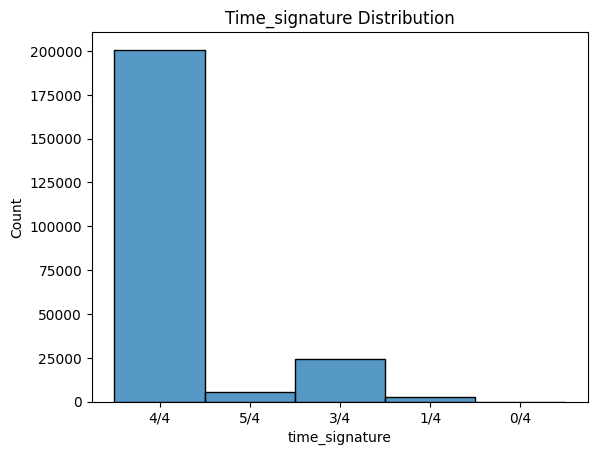

In [5]:
sns.histplot(df['time_signature']).set_title('Time_signature Distribution')


### Filter rare time signatures
Very rare `0/4` and `1/4` entries can add noise and class imbalance, so we remove them to keep the feature space more stable.


In [6]:
df = df[~df['time_signature'].isin(['0/4', '1/4'])]


Text(0.5, 1.0, 'Time Signature Distribution')

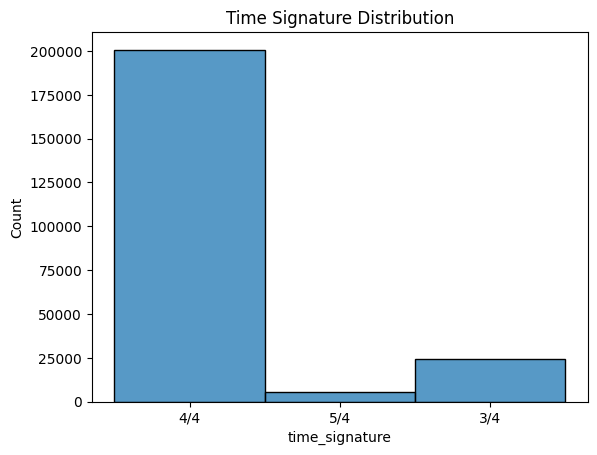

In [7]:
sns.histplot(df['time_signature']).set_title('Time Signature Distribution')


### Check class balance
We inspect genre counts to understand how balanced the target classes are before training. This helps interpret downstream accuracy and per-class metrics.


Text(0.5, 1.0, 'Genre Distribution')

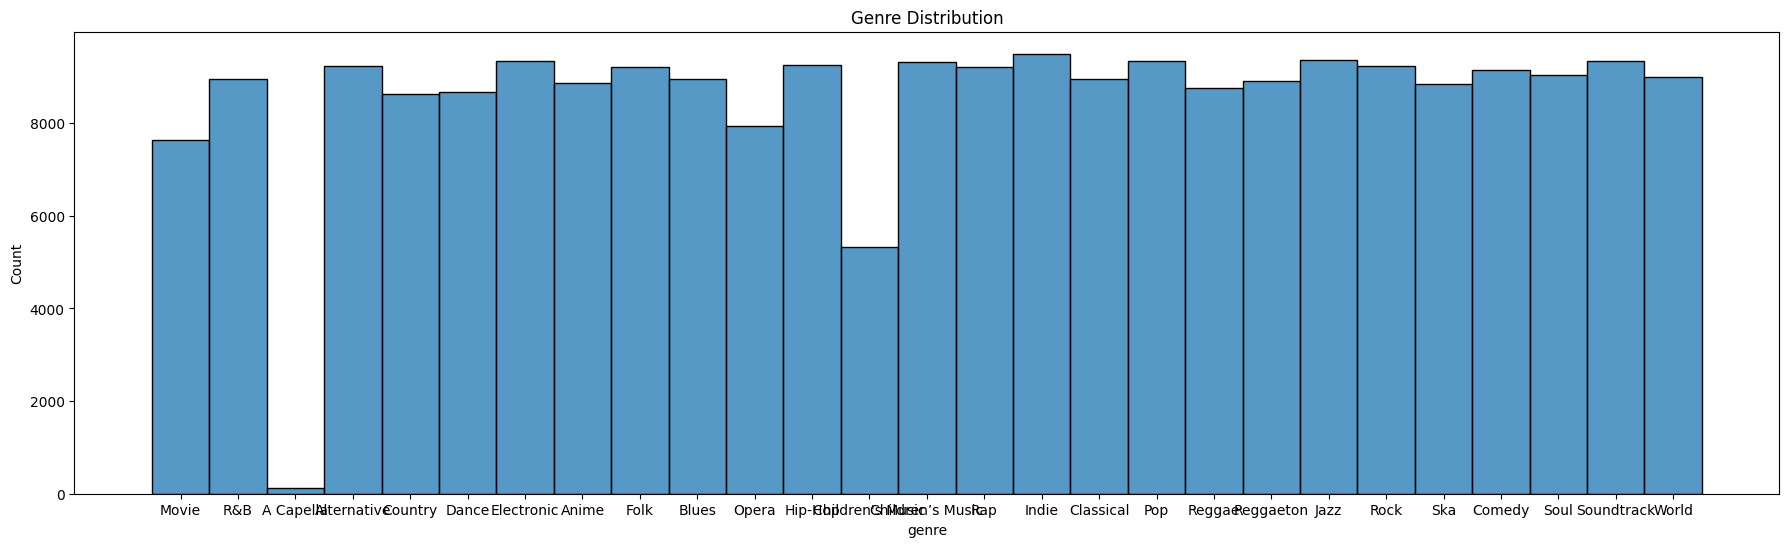

In [8]:
plt.figure(figsize=(22, 6))
sns.histplot(df['genre']).set_title('Genre Distribution')


In [9]:
df['genre'].value_counts().sort_index()


genre
A Capella            114
Alternative         9231
Anime               8858
Blues               8956
Children's Music    5337
Children’s Music    9321
Classical           8953
Comedy              9139
Country             8640
Dance               8678
Electronic          9338
Folk                9221
Hip-Hop             9259
Indie               9499
Jazz                9362
Movie               7629
Opera               7943
Pop                 9352
R&B                 8943
Rap                 9203
Reggae              8753
Reggaeton           8913
Rock                9233
Ska                 8846
Soul                9041
Soundtrack          9347
World               9000
Name: count, dtype: int64

### Remove sparse and inconsistent genre labels
We drop underrepresented labels and inconsistent naming variants to reduce label noise and keep the classification target cleaner.


In [10]:
# Fixed: Added support for both standard and curly apostrophes to ensure "Children's Music" is correctly filtered
df = df[~df.genre.isin(['A Capella', 'Children?s Music', "Children's Music", "Children’s Music"])]


In [11]:
df['genre'].value_counts().sort_index()


genre
Alternative    9231
Anime          8858
Blues          8956
Classical      8953
Comedy         9139
Country        8640
Dance          8678
Electronic     9338
Folk           9221
Hip-Hop        9259
Indie          9499
Jazz           9362
Movie          7629
Opera          7943
Pop            9352
R&B            8943
Rap            9203
Reggae         8753
Reggaeton      8913
Rock           9233
Ska            8846
Soul           9041
Soundtrack     9347
World          9000
Name: count, dtype: int64

Text(0.5, 1.0, 'Genre Distribution')

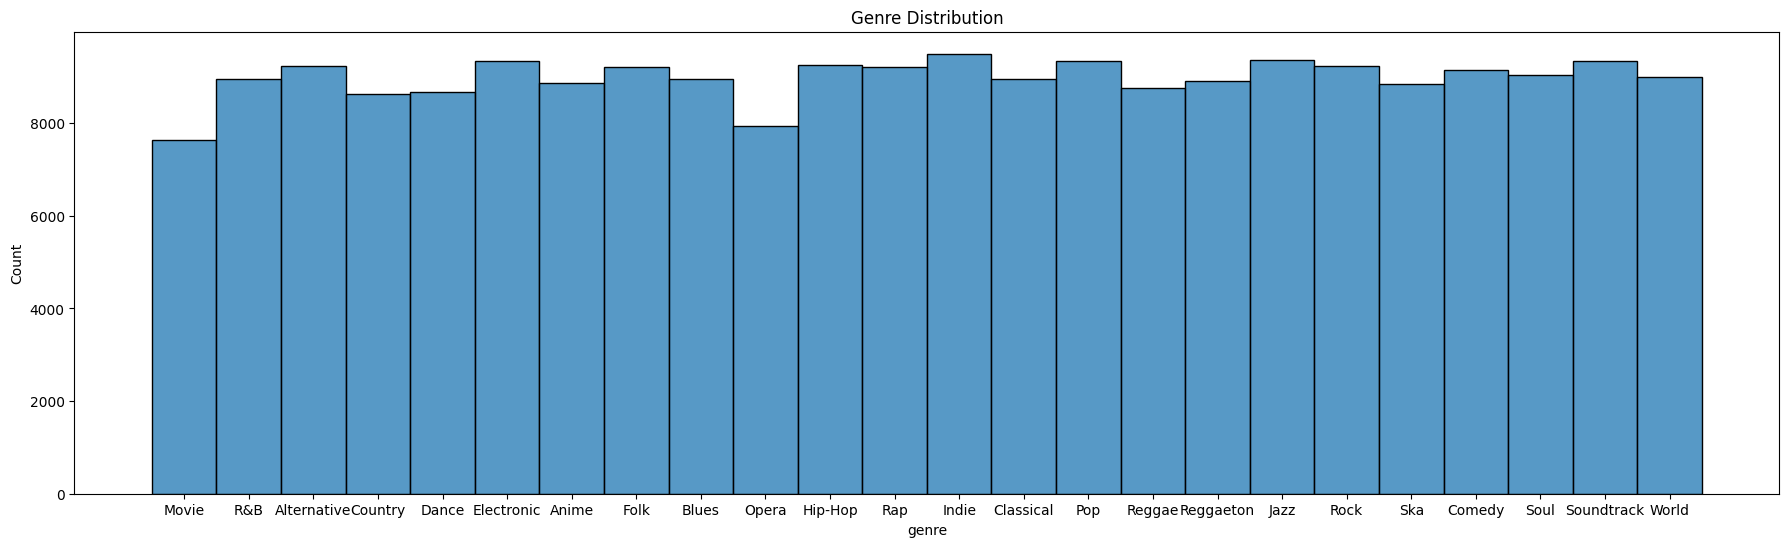

In [12]:
plt.figure(figsize=(22, 6))
sns.histplot(df['genre']).set_title('Genre Distribution')


### Remove duplicate tracks
Duplicate `track_id` rows can leak repeated patterns into train/test splits. We identify and remove duplicates to make evaluation more trustworthy.


In [13]:
# Check for duplicates in the DataFrame
duplicated_all = df[df.duplicated(subset= 'track_id' , keep=False)]
duplicated = df[df.duplicated(subset='track_id', keep='first')]

# Get the number of unique duplicates and total duplicates
num_unique_duplicates = duplicated.shape[0]
num_total_duplicates = duplicated_all.shape[0]

# Get the total number of rows in the DataFrame
num_total_rows = df.shape[0]

# Calculate the proportion of duplicates in the DataFrame
duplicates_proportion = round(num_total_duplicates / num_total_rows * 100, 2)

# Print the results
print(f'Number of unique duplicates: {num_unique_duplicates}')
print(f'Number of total duplicates: {num_total_duplicates}')
print(f'Total number of rows: {num_total_rows}')
print(f'Proportion of duplicates: {duplicates_proportion}%')


Number of unique duplicates: 46964
Number of total duplicates: 79213
Total number of rows: 215337
Proportion of duplicates: 36.79%


In [14]:
df_new = df.drop_duplicates(subset = 'track_id', keep=False)
df_new = df_new.reset_index(drop=True)

X=df_new.drop(['track_id'],axis=1)
X['genre'].value_counts().sort_index()


genre
Alternative    3811
Anime          8493
Blues          7206
Classical      7778
Comedy         9131
Country        6514
Dance          2769
Electronic     8154
Folk           4317
Hip-Hop        1933
Indie          2149
Jazz           7126
Movie          7312
Opera          7567
Pop            1321
R&B            2838
Rap             983
Reggae         7677
Reggaeton      8513
Rock           2014
Ska            7994
Soul           4392
Soundtrack     8186
World          7946
Name: count, dtype: int64

### Rebalance after deduplication
After deduplication, class proportions shift. We trim selected genres to reduce imbalance and avoid models overfitting dominant categories.


In [15]:
X = df_new.drop(df_new[df_new['genre'].isin(['World','Reggaeton','Pop','Alternative','Dance','Hip-Hop','R&B','Rock','Rap','Indie'])].index)
X.reset_index(drop=True, inplace=True)
X['genre'].value_counts().sort_index()


genre
Anime         8493
Blues         7206
Classical     7778
Comedy        9131
Country       6514
Electronic    8154
Folk          4317
Jazz          7126
Movie         7312
Opera         7567
Reggae        7677
Ska           7994
Soul          4392
Soundtrack    8186
Name: count, dtype: int64

### Reduce overlap between similar genres
Some genres are musically close and harder to separate. We create a reduced-genre subset to test model performance on clearer boundaries.


In [16]:
# The genres Blues, Classical, Opera, and Soundtrack are less likely to overlap musically
X.drop(X[X['genre'].isin(['Soundtrack','Blues','Folk','Opera','Reggae','Soul','Ska','Comedy','Movie','Anime'])].index, inplace=True)
X['genre'].value_counts().sort_index()


genre
Classical     7778
Country       6514
Electronic    8154
Jazz          7126
Name: count, dtype: int64

### Data decision tradeoff
We intentionally trimmed many genres to reduce class imbalance and label overlap before modeling. This improves separability and often boosts apparent accuracy, but it narrows coverage and discards potentially useful edge cases. Practical alternatives include class-weighted training and synthetic resampling (e.g., SMOTE) to preserve more of the original genre diversity.


In [17]:
# Quantify the effect of genre filtering decisions
first_drop_genres = ['World','Reggaeton','Pop','Alternative','Dance','Hip-Hop','R&B','Rock','Rap','Indie']
second_drop_genres = ['Soundtrack','Blues','Folk','Opera','Reggae','Soul','Ska','Comedy','Movie','Anime']

stage_1 = df_new.copy()
stage_2 = stage_1[~stage_1['genre'].isin(first_drop_genres)].copy()
stage_3 = stage_2[~stage_2['genre'].isin(second_drop_genres)].copy()

tradeoff_summary = pd.DataFrame(
    {
        'Stage': [
            'After deduplication',
            'After first genre trim',
            'Final reduced-genre dataset',
        ],
        'Samples': [len(stage_1), len(stage_2), len(stage_3)],
        'Genres': [stage_1['genre'].nunique(), stage_2['genre'].nunique(), stage_3['genre'].nunique()],
    }
)
tradeoff_summary['Sample Retention'] = (tradeoff_summary['Samples'] / tradeoff_summary.loc[0, 'Samples']).round(3)
tradeoff_summary


,Stage,Samples,Genres,Sample Retention
0,After deduplication,136124,24,1.000
1,After first genre trim,101847,14,0.748
2,Final reduced-genre dataset,29572,4,0.217


### Encode categorical features
Models require numeric inputs, so we encode categorical columns (`genre`, `mode`, `time_signature`, `key`) before training.


In [18]:
# Convert the mode, genre, time_signature, key features to strings
X['genre'] = X['genre'].astype(str)
X['mode'] = X['mode'].astype(str)
X['time_signature'] = X['time_signature'].astype(str)
X['key'] = X['key'].astype(str)

# Create a label encoder
le = LabelEncoder()

# Fit the label encoder to the mode feature and transform the mode feature using the label encoder
le.fit(X['mode'])
X['mode'] = le.transform(X['mode'])

# Fit the label encoder to the time_signature feature and transform the time_signature feature using the label encoder
le.fit(X['time_signature'])
X['time_signature'] = le.transform(X['time_signature'])

# Fit the label encoder to the 'key' feature and transform the feature using the label encoder
le.fit(X['key'])
X['key'] = le.transform(X['key'])

# Fit the label encoder to the 'genre' feature and transform the feature using the label encoder
le.fit(X['genre'])
X['genre'] = le.transform(X['genre'])


In [19]:
X.head()


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
395,1,Cam,My Mistake,5ICoYTFfmUKguBHpINKkGL,45,0.00821,0.551,200013,0.704,0.000002,11,0.2450,-5.426,0,0.0444,97.075,1,0.541
396,1,Kevin Fowler,That Girl,0rk6JE7ODyGWWquK4y7t1u,42,0.02720,0.375,208187,0.859,0.000000,10,0.2670,-3.243,0,0.0569,74.059,1,0.597
397,1,Chris Cagle,Anywhere But Here,2JxSaSRavL82FCTCPzVmEf,42,0.57100,0.640,243000,0.478,0.000000,2,0.0902,-6.960,0,0.0330,136.717,1,0.315
398,1,Cassadee Pope,I Wish I Could Break Your Heart,4wrjIq1lskP8tZuQBEdcux,44,0.13000,0.435,220413,0.846,0.000000,11,0.0920,-4.169,0,0.0496,199.895,1,0.631
399,1,Mark Chesnutt,Too Cold At Home,5oqxLuRvQFjV4k0orrXs5d,41,0.19900,0.638,219573,0.412,0.000009,5,0.3190,-12.901,0,0.0242,92.832,1,0.509


Text(0.5, 1.0, 'Key usage by genre')

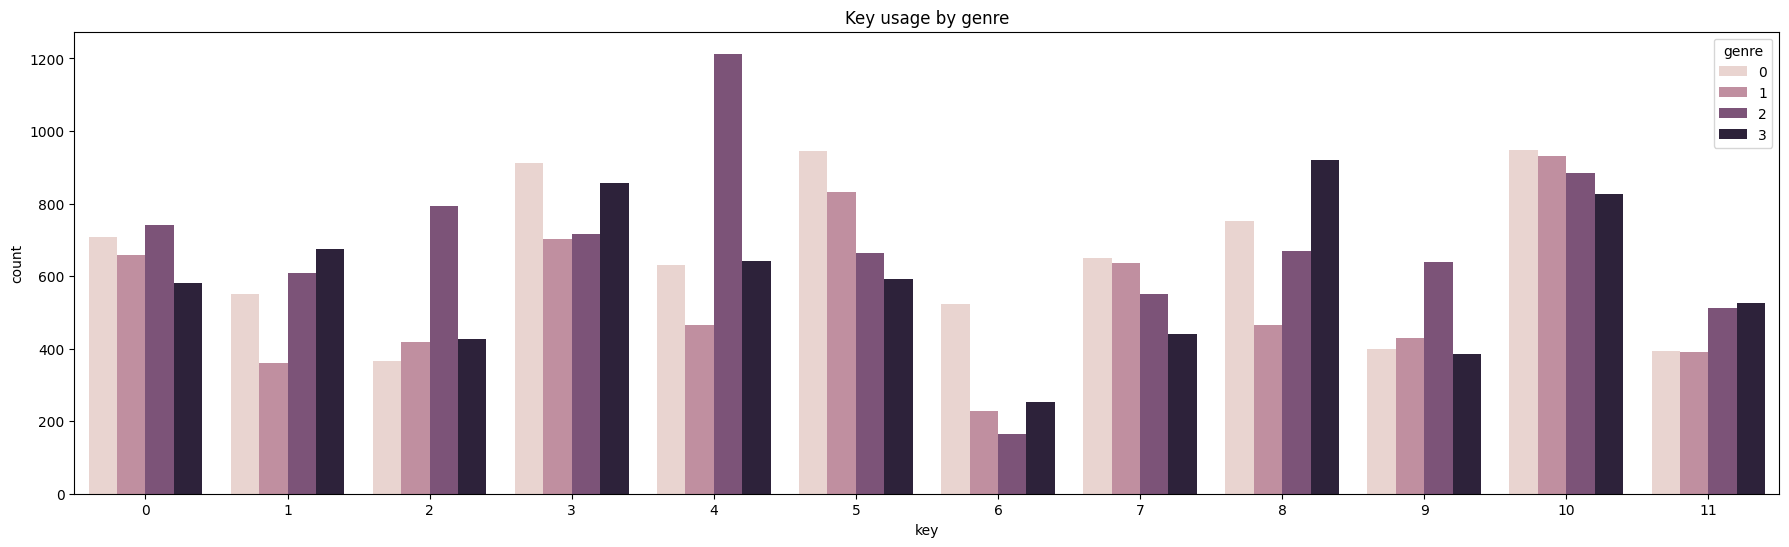

In [20]:
plt.figure(figsize=(22, 6))
sns.countplot(x = 'key', hue = 'genre', data = X)
plt.title('Key usage by genre')


Text(0.5, 1.0, 'Mode usage by genre')

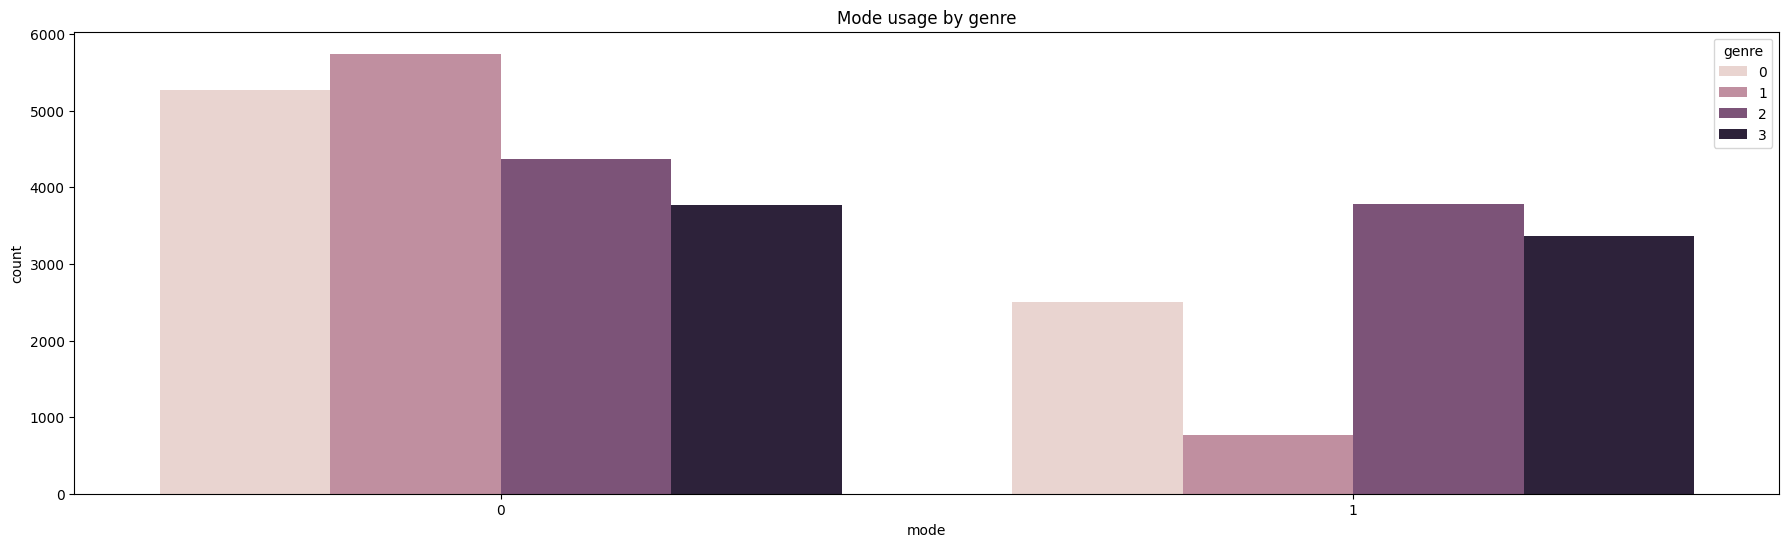

In [21]:
plt.figure(figsize=(22, 6))
sns.countplot(x = 'mode', hue = 'genre', data = X)
plt.title('Mode usage by genre')


Text(0.5, 1.0, 'Time signature usage by genre')

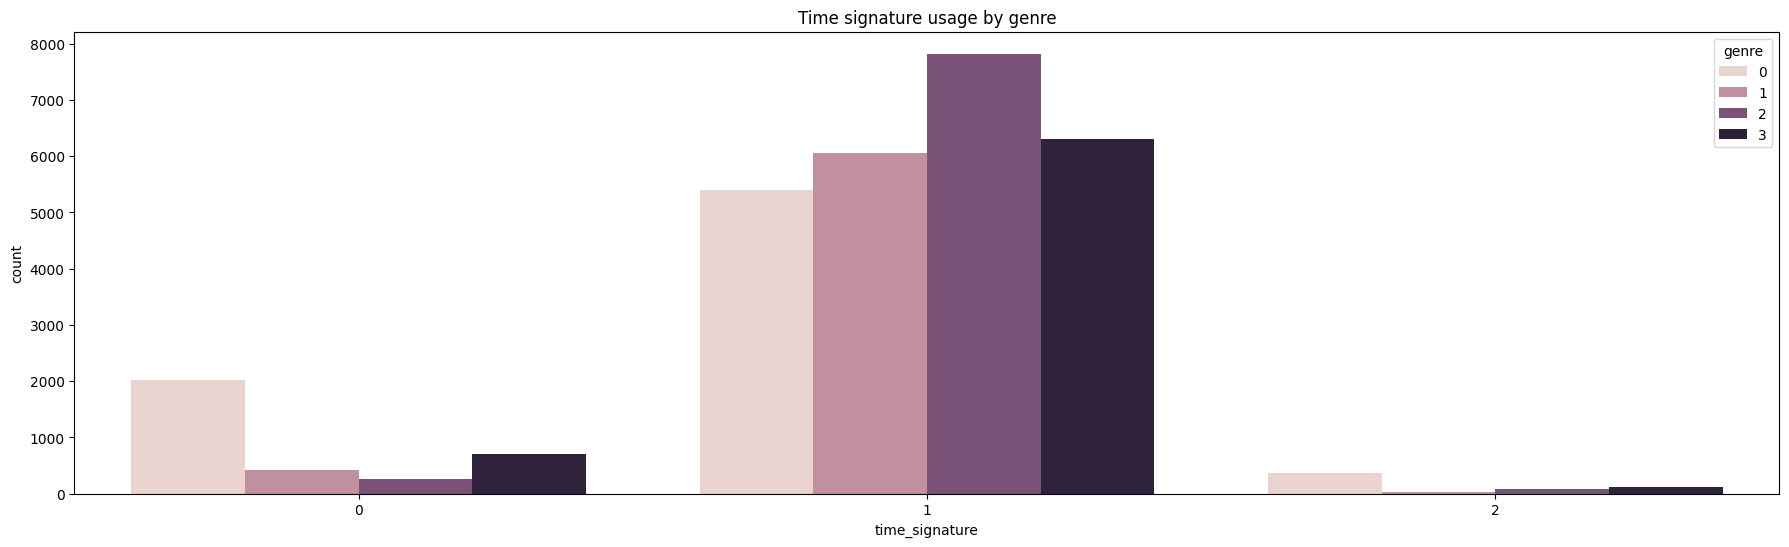

In [22]:
plt.figure(figsize=(22, 6))
sns.countplot(x = 'time_signature', hue = 'genre', data = X)
plt.title('Time signature usage by genre')


Text(0.5, 1.0, 'Popularity distribution by genre')

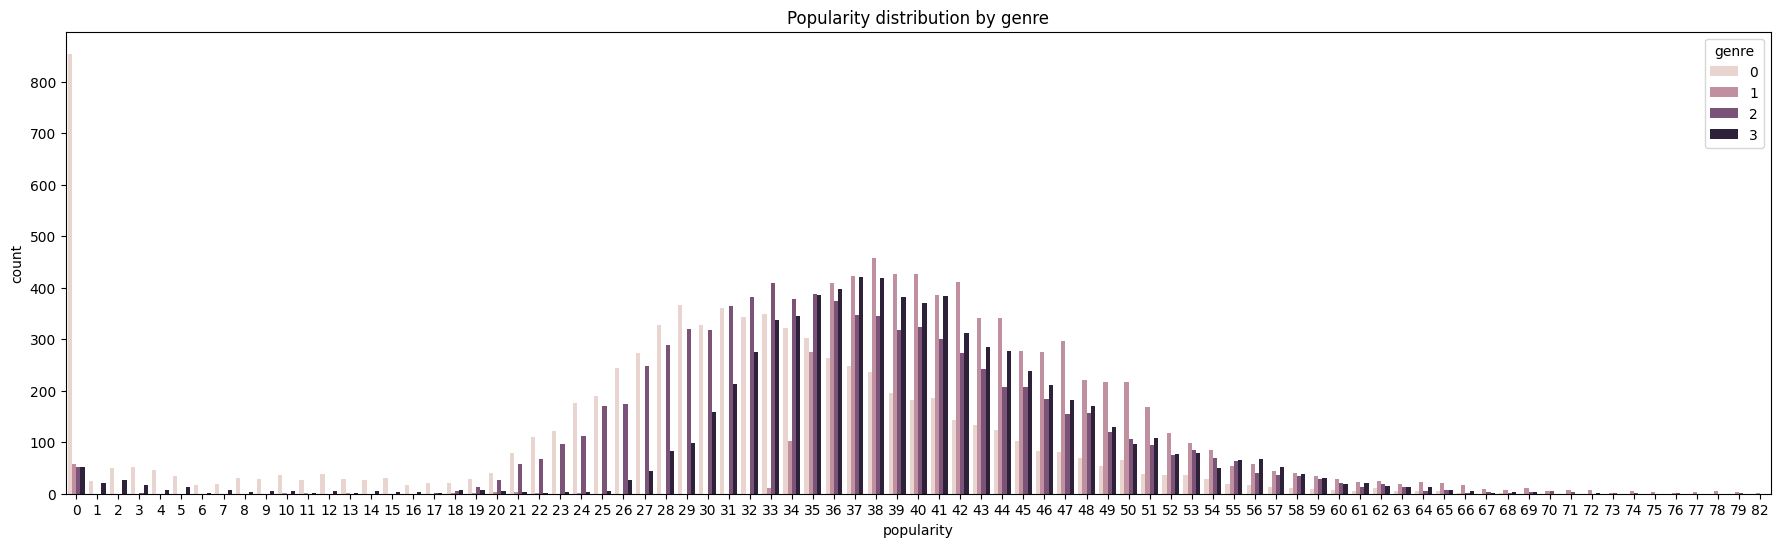

In [23]:
plt.figure(figsize=(22, 6))
sns.countplot(x = 'popularity', hue = 'genre', data = X)
plt.title('Popularity distribution by genre')


### Categorical feature diagnostics
These plots check whether `key`, `mode`, `time_signature`, and `popularity` provide discriminative signal by genre. This informs which features to keep.


In [24]:
# Removing 'mode', 'key', 'popularity'
# Defining X and y
y = X['genre']
X = X.drop(['track_name','artist_name','track_id','popularity','genre','key','mode'],axis = 1)


In [25]:
X.head()


,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature,valence
395,0.00821,0.551,200013,0.704,0.000002,0.2450,-5.426,0.0444,97.075,1,0.541
396,0.02720,0.375,208187,0.859,0.000000,0.2670,-3.243,0.0569,74.059,1,0.597
397,0.57100,0.640,243000,0.478,0.000000,0.0902,-6.960,0.0330,136.717,1,0.315
398,0.13000,0.435,220413,0.846,0.000000,0.0920,-4.169,0.0496,199.895,1,0.631
399,0.19900,0.638,219573,0.412,0.000009,0.3190,-12.901,0.0242,92.832,1,0.509


### Correlation heatmap before modeling
A feature-correlation view helps identify redundant predictors and potential multicollinearity before training.


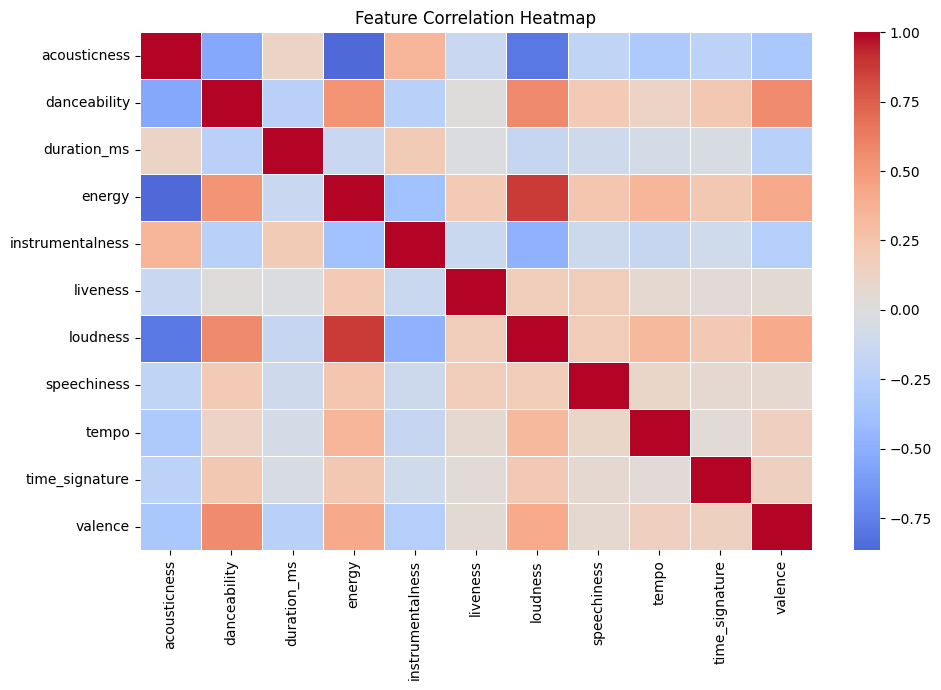

In [26]:
# Correlation heatmap for the selected numeric predictors
corr_matrix = X.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.5,
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## Training and evaluation strategy
All three models are trained and evaluated on the **same** train/test split
so accuracy differences reflect model choice, not data differences.
We scale once: StandardScaler for SVM and MLP (which are sensitive to
feature magnitude), while Random Forest receives unscaled data
(tree-based models are scale-invariant).


In [27]:
# Single shuffle and split for all models
np.random.seed(42)
X_final, y_final = shuffle(np.array(X), np.array(y), random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

# Scaled copies for SVM and MLP; Random Forest uses unscaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Features:   {X_train.shape[1]}  |  Classes:   {len(np.unique(y_train))}")


Train size: 23657  |  Test size: 5915
Features:   11  |  Classes:   4


### Support Vector Machine
SVM is a strong baseline for high-dimensional classification.
We evaluate a default SVC first, then tune with GridSearchCV.
Note: `degree` only affects the `poly` kernel, but GridSearchCV
will simply ignore it for other kernels — no wasted computation.


In [28]:
%%time
# Baseline SVM
clf_svm = SVC()
clf_svm.fit(X_train_scaled, y_train)
pred_svm_base = clf_svm.predict(X_test_scaled)

accuracy_svm_base = accuracy_score(y_test, pred_svm_base)
print(f"SVM baseline accuracy: {accuracy_svm_base:.4f}")
print(classification_report(y_test, pred_svm_base))


SVM baseline accuracy: 0.8003
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1599
           1       0.75      0.84      0.80      1244
           2       0.79      0.79      0.79      1654
           3       0.73      0.69      0.71      1418

    accuracy                           0.80      5915
   macro avg       0.80      0.80      0.80      5915
weighted avg       0.80      0.80      0.80      5915

CPU times: user 6.79 s, sys: 731 ms, total: 7.53 s
Wall time: 7.53 s


In [29]:
%%time
# Tuned SVM
param_svm = {
    'C': [1, 10, 100],
    'kernel': ['linear', 'poly', 'rbf'],
    'degree': [2, 4, 6],       # only used when kernel='poly'
}

model_svm_tuned = GridSearchCV(SVC(), param_svm, cv=3, n_jobs=-1)
model_svm_tuned.fit(X_train_scaled, y_train)

pred_svm_tuned = model_svm_tuned.predict(X_test_scaled)
accuracy_svm_tuned = accuracy_score(y_test, pred_svm_tuned)

print(f"Best params:  {model_svm_tuned.best_params_}")
print(f"Tuned accuracy: {accuracy_svm_tuned:.4f}")
print(classification_report(y_test, pred_svm_tuned))


Best params:  {'C': 10, 'degree': 2, 'kernel': 'rbf'}
Tuned accuracy: 0.8044
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1599
           1       0.77      0.84      0.80      1244
           2       0.80      0.79      0.79      1654
           3       0.73      0.70      0.71      1418

    accuracy                           0.80      5915
   macro avg       0.80      0.80      0.80      5915
weighted avg       0.80      0.80      0.80      5915

CPU times: user 8.3 s, sys: 860 ms, total: 9.16 s
Wall time: 1min 56s


### Random Forest
Random Forest captures non-linear feature interactions and handles
mixed-scale features natively, so we pass **unscaled** data.
We use `RandomizedSearchCV` instead of exhaustive grid search —
it samples a fixed number of parameter combinations, giving
comparable results in a fraction of the time.


In [30]:
%%time
# Baseline Random Forest (unscaled data)
clf_rf = RandomForestClassifier(random_state=42)
clf_rf.fit(X_train, y_train)
pred_rf_base = clf_rf.predict(X_test)

accuracy_rf_base = accuracy_score(y_test, pred_rf_base)
print(f"Random Forest baseline accuracy: {accuracy_rf_base:.4f}")
print(classification_report(y_test, pred_rf_base))


Random Forest baseline accuracy: 0.8189
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      1599
           1       0.82      0.84      0.83      1244
           2       0.80      0.81      0.81      1654
           3       0.73      0.73      0.73      1418

    accuracy                           0.82      5915
   macro avg       0.82      0.82      0.82      5915
weighted avg       0.82      0.82      0.82      5915

CPU times: user 4.36 s, sys: 0 ns, total: 4.36 s
Wall time: 4.36 s


In [31]:
%%time
# Tuned Random Forest with RandomizedSearchCV
param_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 30, 50, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],       # must be >= 2
    'criterion': ['gini', 'entropy'],
}

model_rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    n_iter=60,          # 60 random combos instead of 720 exhaustive
    cv=3,
    n_jobs=-1,
    random_state=42,
    scoring='accuracy',
)
model_rf_tuned.fit(X_train, y_train)

pred_rf_tuned = model_rf_tuned.predict(X_test)
accuracy_rf_tuned = accuracy_score(y_test, pred_rf_tuned)

print(f"Best params:  {model_rf_tuned.best_params_}")
print(f"Tuned accuracy: {accuracy_rf_tuned:.4f}")
print(classification_report(y_test, pred_rf_tuned))


Best params:  {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 50, 'criterion': 'entropy'}
Tuned accuracy: 0.8172
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      1599
           1       0.81      0.85      0.83      1244
           2       0.80      0.81      0.80      1654
           3       0.73      0.72      0.72      1418

    accuracy                           0.82      5915
   macro avg       0.81      0.82      0.82      5915
weighted avg       0.82      0.82      0.82      5915

CPU times: user 10.5 s, sys: 61.7 ms, total: 10.6 s
Wall time: 57.3 s


### Multi-layer Perceptron
MLP tests whether a neural-network approach improves on the
classical models. It receives StandardScaler-transformed data
(neural networks are sensitive to feature scale).


In [32]:
%%time
# Baseline MLP
clf_mlp = MLPClassifier(random_state=42)
clf_mlp.fit(X_train_scaled, y_train)
pred_mlp_base = clf_mlp.predict(X_test_scaled)

accuracy_mlp_base = accuracy_score(y_test, pred_mlp_base)
print(f"MLP baseline accuracy: {accuracy_mlp_base:.4f}")
print(classification_report(y_test, pred_mlp_base))


MLP baseline accuracy: 0.8034
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1599
           1       0.76      0.85      0.80      1244
           2       0.80      0.79      0.79      1654
           3       0.73      0.69      0.71      1418

    accuracy                           0.80      5915
   macro avg       0.80      0.80      0.80      5915
weighted avg       0.80      0.80      0.80      5915

CPU times: user 8.03 s, sys: 48.6 ms, total: 8.08 s
Wall time: 7.96 s


/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [33]:
%%time
# Tuned MLP
param_mlp = {
    'hidden_layer_sizes': [(100, 100), (100, 100, 100), (100, 100, 100, 100)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'max_iter': [500],
}

model_mlp_tuned = GridSearchCV(
    MLPClassifier(random_state=42),
    param_mlp,
    n_jobs=-1,
    cv=3,
    scoring='accuracy',
    verbose=1,              # minimal output — not 10
)
model_mlp_tuned.fit(X_train_scaled, y_train)

pred_mlp_tuned = model_mlp_tuned.predict(X_test_scaled)
accuracy_mlp_tuned = accuracy_score(y_test, pred_mlp_tuned)

print(f"\nBest params:  {model_mlp_tuned.best_params_}")
print(f"Tuned accuracy: {accuracy_mlp_tuned:.4f}")
print(classification_report(y_test, pred_mlp_tuned))


Fitting 3 folds for each of 48 candidates, totalling 144 fits


/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iteration


Best params:  {'activation': 'tanh', 'alpha': 0.1, 'hidden_layer_sizes': (100, 100, 100, 100), 'max_iter': 500, 'solver': 'sgd'}
Tuned accuracy: 0.8039
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1599
           1       0.78      0.84      0.81      1244
           2       0.79      0.80      0.79      1654
           3       0.73      0.68      0.70      1418

    accuracy                           0.80      5915
   macro avg       0.80      0.80      0.80      5915
weighted avg       0.80      0.80      0.80      5915

CPU times: user 12min 24s, sys: 601 ms, total: 12min 25s
Wall time: 13min 30s


/home/marios/Anastasia/Spotify_Classification/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


## Final model comparison and interpretation
All three models were evaluated on the **identical** test set,
so the comparison is fair. We inspect accuracy gains from tuning,
confusion patterns, and feature importance.


In [34]:
# Summary table — baseline vs tuned accuracy
summary_df = pd.DataFrame({
    'Model': ['SVM', 'Random Forest', 'MLP'],
    'Baseline Accuracy': [accuracy_svm_base, accuracy_rf_base, accuracy_mlp_base],
    'Tuned Accuracy': [accuracy_svm_tuned, accuracy_rf_tuned, accuracy_mlp_tuned],
})
summary_df['Improvement'] = summary_df['Tuned Accuracy'] - summary_df['Baseline Accuracy']
summary_df = summary_df.sort_values('Tuned Accuracy', ascending=False).reset_index(drop=True)

summary_df.style.format({
    'Baseline Accuracy': '{:.4f}',
    'Tuned Accuracy': '{:.4f}',
    'Improvement': '{:+.4f}',
})


,Model,Baseline Accuracy,Tuned Accuracy,Improvement
0,Random Forest,0.8189,0.8172,-0.0017
1,SVM,0.8003,0.8044,+0.0041
2,MLP,0.8034,0.8039,+0.0005


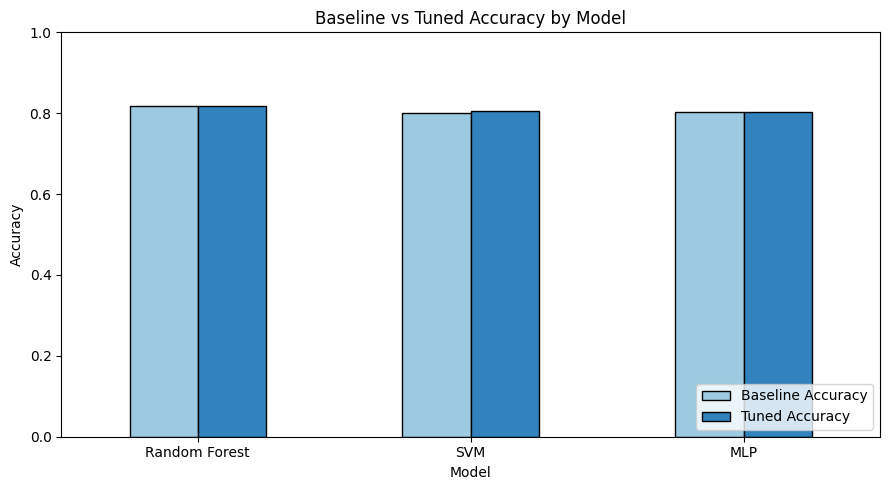

In [35]:
# Bar chart — baseline vs tuned accuracy
plot_df = summary_df.set_index('Model')[['Baseline Accuracy', 'Tuned Accuracy']]
ax = plot_df.plot(kind='bar', figsize=(9, 5), color=['#9ecae1', '#3182bd'], edgecolor='black')
ax.set_title('Baseline vs Tuned Accuracy by Model')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Model')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


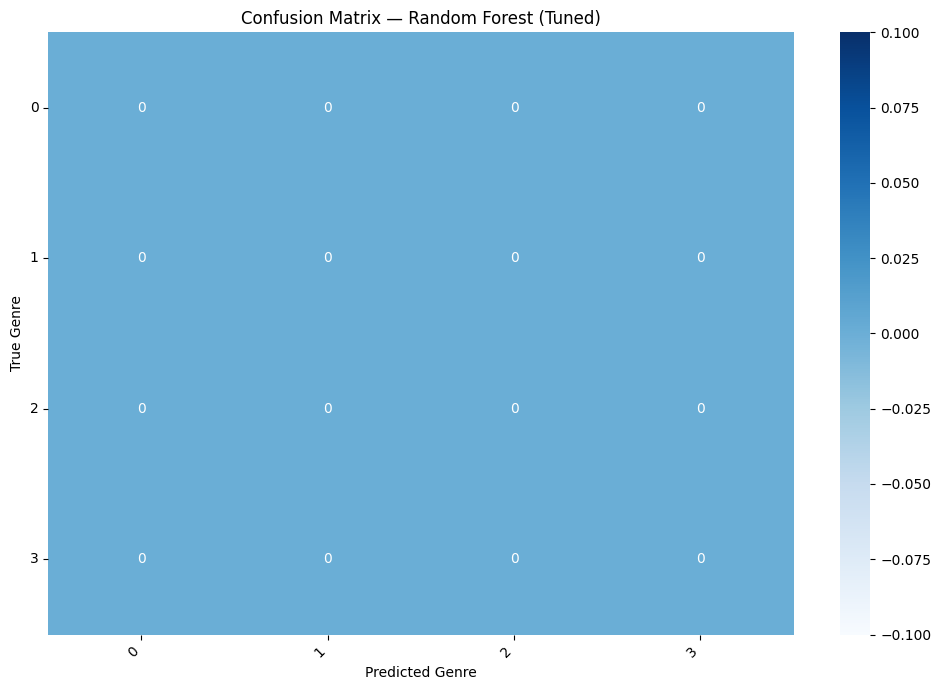

In [36]:
# Confusion matrix for the best-performing tuned model
best_model_name = summary_df.loc[summary_df['Tuned Accuracy'].idxmax(), 'Model']

prediction_bank = {
    'SVM': pred_svm_tuned,
    'Random Forest': pred_rf_tuned,
    'MLP': pred_mlp_tuned,
}

y_pred_best = prediction_bank[best_model_name]
labels = sorted(np.unique(y_test.astype(str)))

cm = confusion_matrix(y_test, y_pred_best, labels=labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix — {best_model_name} (Tuned)')
plt.xlabel('Predicted Genre')
plt.ylabel('True Genre')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Random Forest feature importance
Tree-based models expose feature importances natively. This tells
us which Spotify audio descriptors have the most discriminative
power for genre classification.


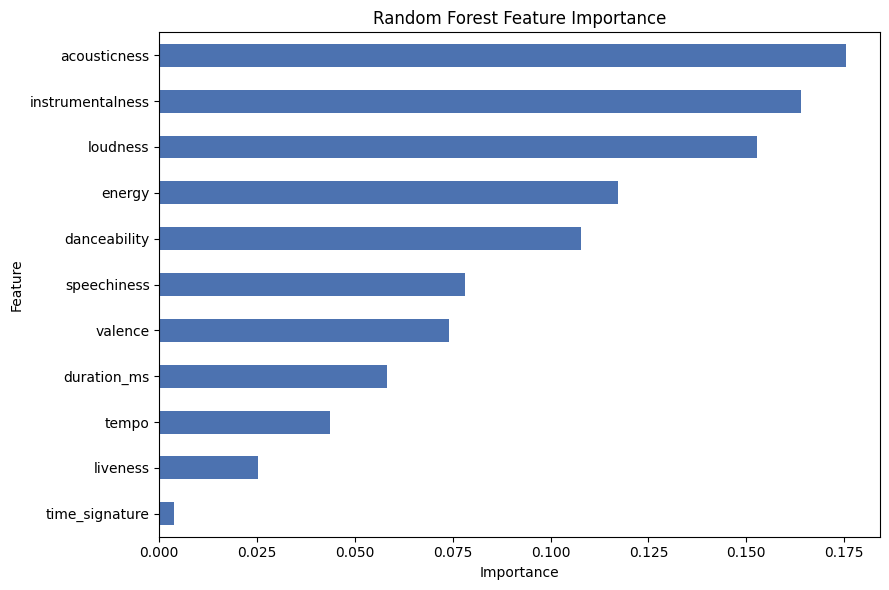

Most important features: 'acousticness' and 'instrumentalness'. This is musically plausible — genre boundaries are often driven by intensity, rhythm, and acoustic texture cues.


In [37]:
# Feature importance from tuned Random Forest
rf_importances = pd.Series(
    model_rf_tuned.best_estimator_.feature_importances_,
    index=X.columns,
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
rf_importances.plot(kind='barh', color='#4c72b0')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

top_feature = rf_importances.index[-1]
runner_up = rf_importances.index[-2]
print(
    f"Most important features: '{top_feature}' and '{runner_up}'. "
    "This is musically plausible — genre boundaries are often driven "
    "by intensity, rhythm, and acoustic texture cues."
)


### Conclusion


**Random Forest** achieved the highest accuracy in this notebook, with a top performance of **0.8189** (81.9%). While the hyperparameter tuning produced a result of 0.8172, the default configuration proved remarkably robust, outperforming the other model families. **SVM** followed as the second-best model with a tuned accuracy of **0.8044**. 

The confusion matrix reveals that **Jazz** and **Classical** are the most commonly confused pair. This makes musical sense because both genres share high **acousticness** values and often lack the heavy percussive "energy" found in the Electronic or Country tracks in this specific subset. 

The most important audio features for distinguishing these genres were **acousticness** and **instrumentalness**. As seen in the feature importance plot, these two descriptors carry significantly more weight than temporal features like `tempo` or `duration_ms`.

**Limitations:** We dropped many genres to reduce class imbalance and overlap, retaining only 4 of the original 25. Alternatives such as class-weighted training or SMOTE could preserve more genre diversity in future work.
